# 📘 Assignment: Sentiment Analysis using NLP Pipeline & ML Models

## 🎯 Objective
Build a complete end-to-end **Sentiment Analysis system** by applying:
- NLP preprocessing
- Feature engineering
- Multiple Machine Learning models  

Compare their performance using evaluation metrics.

---

## 📝 Task Description
You are required to build a **Sentiment Analysis model** using a real-world dataset from Kaggle.  
The goal is to understand how raw text is:
1. Processed
2. Transformed into features
3. Used in ML models

---

## 📂 Dataset Requirement
- **Source:** Kaggle  
- **Examples:**
  - IMDb Reviews Dataset    

The dataset must contain **text data with sentiment labels**:
- Positive  
- Negative  
- Neutral  

## Environment Setup & Data Extraction

In [14]:
# Cell 1: Environment Setup & Data Extraction
import os
import zipfile
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Extract Dataset (UPDATE zip_path IF NEEDED)
zip_path = '/content/drive/MyDrive/IMDB_Dataset.zip'
extract_dir = '/content/dataset'
os.makedirs(extract_dir, exist_ok=True)

# Unzip only if it hasn't been extracted yet
if not os.path.exists(os.path.join(extract_dir, 'IMDB Dataset.csv')):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting /content/drive/MyDrive/IMDB_Dataset.zip...
Extraction complete!


## Data Loading & Understanding

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('/content/dataset/IMDB Dataset.csv')

# 2. Explore number of samples
print(f"Dataset Shape: {df.shape}")

# 3. Class distribution
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# 4. Sample texts
print("\nSample Reviews:")
for i in range(3):
    print(f"[{df['sentiment'].iloc[i]}] - {df['review'].iloc[i][:150]}...")

Dataset Shape: (50000, 2)

Class Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample Reviews:
[positive] - One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with...
[positive] - A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes d...
[positive] - I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted come...


## NLP Preprocessing

In [16]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

print("Applying preprocessing... (This may take a minute or two)")
df['cleaned_review'] = df['review'].apply(preprocess_text)
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("Preprocessing complete!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Applying preprocessing... (This may take a minute or two)
Preprocessing complete!


## Feature Engineering

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 1. Train-Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_review'], df['label'], test_size=0.2, random_state=42
)

# 2. Vectorization - Bag of Words (BoW)
print("Applying Bag of Words...")
count_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = count_vectorizer.fit_transform(X_train_raw)
X_test_bow = count_vectorizer.transform(X_test_raw)

# 3. Vectorization - TF-IDF
print("Applying TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vectorizer.transform(X_test_raw)

print(f"BoW Matrix Shape: {X_train_bow.shape}")
print(f"TF-IDF Matrix Shape: {X_train_tfidf.shape}")

Applying Bag of Words...
Applying TF-IDF...
BoW Matrix Shape: (40000, 5000)
TF-IDF Matrix Shape: (40000, 5000)


## Model Training & Evaluation

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = [] # Initialize results list

# Helper function to train, evaluate, and store metrics
def evaluate_and_store(model, X_train, y_train, X_test, y_test, model_name, feature_type):
    print(f"Training {model_name} with {feature_type} features...")
    model.fit(X_train, y_train) # Train

    y_pred = model.predict(X_test) # Predict

    # Evaluate and store
    results.append({
        'Model': model_name,
        'Features': feature_type,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted')
    })
    print(f"--- {model_name} ({feature_type}) Results ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

print("Training models... Please wait.")

# Initialize models
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
nb_model = MultinomialNB()
tree_model = DecisionTreeClassifier(random_state=42)

# Train and Evaluate all models with both BoW and TF-IDF features
evaluate_and_store(log_reg_model, X_train_bow, y_train, X_test_bow, y_test, 'Logistic Regression', 'BoW')
evaluate_and_store(log_reg_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Logistic Regression', 'TF-IDF')

evaluate_and_store(nb_model, X_train_bow, y_train, X_test_bow, y_test, 'Naive Bayes', 'BoW')
evaluate_and_store(nb_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Naive Bayes', 'TF-IDF')

# Decision Tree can be computationally intensive with large max_depth, limiting for faster execution
evaluate_and_store(tree_model, X_train_bow, y_train, X_test_bow, y_test, 'Decision Tree', 'BoW')
evaluate_and_store(tree_model, X_train_tfidf, y_train, X_test_tfidf, y_test, 'Decision Tree', 'TF-IDF')

print("Model training and evaluation complete!")

Training models... Please wait.
Training Logistic Regression with BoW features...
--- Logistic Regression (BoW) Results ---
Accuracy:  0.8725
Precision: 0.8725
Recall:    0.8725
F1 Score:  0.8725

Training Logistic Regression with TF-IDF features...
--- Logistic Regression (TF-IDF) Results ---
Accuracy:  0.8856
Precision: 0.8858
Recall:    0.8856
F1 Score:  0.8856

Training Naive Bayes with BoW features...
--- Naive Bayes (BoW) Results ---
Accuracy:  0.8451
Precision: 0.8452
Recall:    0.8451
F1 Score:  0.8451

Training Naive Bayes with TF-IDF features...
--- Naive Bayes (TF-IDF) Results ---
Accuracy:  0.8491
Precision: 0.8491
Recall:    0.8491
F1 Score:  0.8491

Training Decision Tree with BoW features...
--- Decision Tree (BoW) Results ---
Accuracy:  0.7200
Precision: 0.7202
Recall:    0.7200
F1 Score:  0.7200

Training Decision Tree with TF-IDF features...
--- Decision Tree (TF-IDF) Results ---
Accuracy:  0.7125
Precision: 0.7126
Recall:    0.7125
F1 Score:  0.7125

Model training a

## Results Comparison & Visualization

--- Model Performance Comparison ---


,Model,Features,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,TF-IDF,0.8856,0.8858,0.8856,0.8856
0,Logistic Regression,BoW,0.8725,0.8725,0.8725,0.8725
3,Naive Bayes,TF-IDF,0.8491,0.8491,0.8491,0.8491
2,Naive Bayes,BoW,0.8451,0.8452,0.8451,0.8451
4,Decision Tree,BoW,0.7200,0.7202,0.7200,0.7200
5,Decision Tree,TF-IDF,0.7125,0.7126,0.7125,0.7125


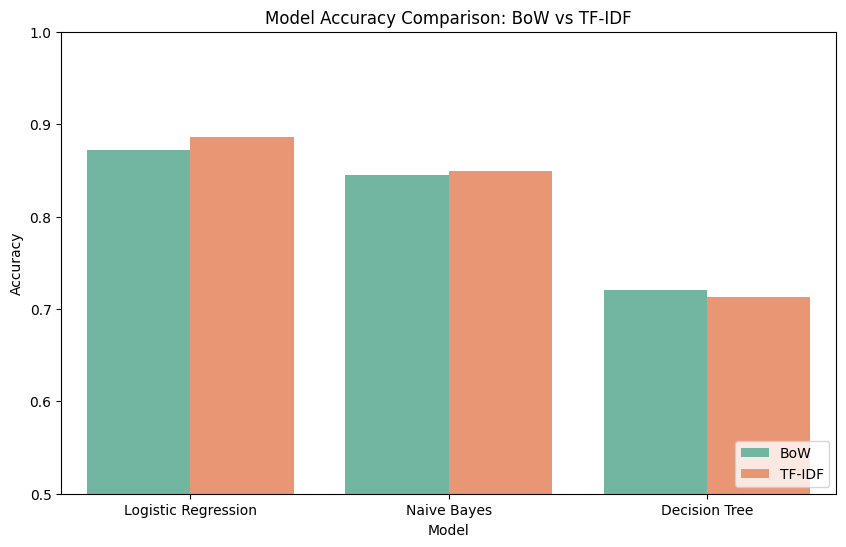

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert our list of dictionaries into a Pandas DataFrame
results_df = pd.DataFrame(results)

print("--- Model Performance Comparison ---")
# Display table sorted by F1 Score (best performance at the top)
display(results_df.sort_values(by='F1 Score', ascending=False).round(4))

# Plotting the Accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Features', palette='Set2')
plt.title('Model Accuracy Comparison: BoW vs TF-IDF')
plt.ylim(0.5, 1.0) # Zooming in on relevant accuracy range
plt.legend(loc='lower right')
plt.show()

# Sentiment Analysis: Comparison & Insights

##  Best Preprocessing Steps
- **Text Normalization**: Lowercasing, removing HTML tags, and punctuation.
- **Lemmatization**: Reduces vocabulary size while preserving semantic meaning.
-  This combination effectively minimizes noise and keeps sentiment-bearing words intact.



## Best Vectorization
- **TF-IDF** outperformed **Bag of Words (BoW)**:
  - Logistic Regression: **88.56%** (TF-IDF) vs **87.25%** (BoW)
  - Naive Bayes: **84.91%** (TF-IDF) vs **84.51%** (BoW)
-  TF-IDF penalizes overly common words and highlights rarer, sentiment-rich words.




## Best Model
- **Logistic Regression (trained on TF-IDF)**:
  - Accuracy, Precision, Recall, and F1 Score ≈ **88.56%**
  - Excels at capturing linear relationships in high-dimensional, sparse text data.


## Trade-Offs

### Logistic Regression
-  Highest accuracy and balanced metrics.
-  Requires more computation time to optimize weights.

### Naive Bayes
-  Extremely fast training and scalable.
-  Slightly lower accuracy (~84.9%) due to independence assumption.

### Decision Tree
-  Worst performer (71.25% - 72.00%).
-  Struggles with sparse matrices and prone to overfitting in NLP tasks.



##  Summary Table

| Model              | Vectorization | Accuracy | Key Strengths | Key Weaknesses |
|--------------------|---------------|----------|---------------|----------------|
| Logistic Regression| TF-IDF        | 88.56%   | Best balance of metrics | Slower training |
| Naive Bayes        | TF-IDF        | 84.91%   | Fast, scalable baseline | Independence assumption hurts accuracy |
| Decision Tree      | BoW/TF-IDF    | ~71-72%  | Interpretability | Overfits, poor with sparse data |




## Key Takeaway
For sentiment analysis, the **optimal pipeline** is:
**Text Normalization + Lemmatization → TF-IDF → Logistic Regression**

This setup balances accuracy, interpretability, and robustness for real-world NLP tasks.